# statarb_live — Trade-price Verification vs real MT5 data

**Goal:** check whether the entry/exit prices recorded by the paper bot are the *real* MT5
prices at the bar the bot acted on. For every fill of every closed trade we pull H1 bars from
MT5 (**20 before, 20 after** the relevant bar) and test whether the logged price sits inside the
bar's [low, high] range at the **signal bar's timestamp**.

**Hypothesis under test:** the first cycle after MT5 connect traded on *stale* data — newly
`symbol_select`'d symbols returned old history, and the inner-join aligned the panel to the oldest
common bar (~3 weeks back). If true, the recorded **entry** prices match a far-earlier date, while
the **exit** prices (later cycles, fresh data) match the real bar — making the trade PnL an artifact.

Re-run top-to-bottom on the machine that has the MT5 terminal logged in (Errante demo).

In [1]:
import sqlite3, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import MetaTrader5 as mt5

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB   = REPO / 'statarb_live' / '_data' / 'statarb_live.db'
SNAP = REPO / 'statarb_live' / '_data' / '_closed_fills_snapshot.json'
BARS_PAD = 20            # candles before/after to pull
TF = mt5.TIMEFRAME_H1

assert mt5.initialize(), f'MT5 initialize failed: {mt5.last_error()}'
ai = mt5.account_info()
print('MT5 connected:', None if ai is None else (ai.login, ai.server))

MT5 connected: (13399867, 'ErranteSC-Demo')


In [2]:
# --- load the closed-trade fills (from the live DB, or the JSON snapshot fallback) ---
if DB.exists():
    cx = sqlite3.connect(DB); cx.row_factory = sqlite3.Row
    fills = [dict(r) for r in cx.execute(
        """SELECT pair_key, symbol, leg, kind, side, volume, intended_price, actual_price,
                  signal_ts, fill_ts
           FROM fills WHERE position_id IN (SELECT position_id FROM trades)
           ORDER BY fill_ts""").fetchall()]
    cx.close()
    src = 'live DB'
else:
    fills = json.load(open(SNAP)); src = 'JSON snapshot'
fills = pd.DataFrame(fills)
print(f'{len(fills)} fills loaded from {src}')
fills

12 fills loaded from live DB


,pair_key,symbol,leg,kind,side,volume,intended_price,actual_price,signal_ts,fill_ts
0,CADCHF~EURCAD,CADCHF,y,entry,buy,0.32,0.56784,0.567918,2026-05-22 23:00:00.000000,2026-06-11 13:34:45.990078
1,CADCHF~EURCAD,EURCAD,x,entry,buy,0.10,1.60348,1.603575,2026-05-22 23:00:00.000000,2026-06-11 13:34:45.990115
2,AUDUSD~USDCAD,AUDUSD,y,entry,sell,0.23,0.71286,0.712798,2026-05-22 23:00:00.000000,2026-06-11 13:34:45.998170
3,AUDUSD~USDCAD,USDCAD,x,entry,sell,0.14,1.38211,1.382008,2026-05-22 23:00:00.000000,2026-06-11 13:34:45.998193
4,EURCAD~EURGBP,EURCAD,y,entry,buy,0.17,1.60348,1.603588,2026-05-22 23:00:00.000000,2026-06-11 13:34:46.003597
5,EURCAD~EURGBP,EURGBP,x,entry,buy,0.05,0.86349,0.863561,2026-05-22 23:00:00.000000,2026-06-11 13:34:46.003621
6,CADCHF~EURCAD,CADCHF,NaN,exit,sell,0.32,0.56887,0.568786,NaN,2026-06-12 00:00:59.814358
7,CADCHF~EURCAD,EURCAD,NaN,exit,sell,0.10,1.61748,1.617369,NaN,2026-06-12 00:00:59.817107
8,AUDUSD~USDCAD,AUDUSD,NaN,exit,buy,0.23,0.70511,0.705170,NaN,2026-06-12 00:00:59.829941
9,AUDUSD~USDCAD,USDCAD,NaN,exit,buy,0.14,1.39636,1.396454,NaN,2026-06-12 00:00:59.831228


In [3]:
# --- helpers: resolve broker symbol (Errante uses .i on crosses) + pull H1 around a time ---
_resolved = {}
def resolve(sym):
    if sym in _resolved: return _resolved[sym]
    for suf in ('', '.i', '.m', '.ecn', '.pro', '.raw'):
        if mt5.symbol_info(sym + suf) is not None:
            mt5.symbol_select(sym + suf, True); _resolved[sym] = sym + suf; return sym + suf
    _resolved[sym] = None; return None

def pull_h1(sym, center_ts, pad=BARS_PAD):
    """H1 bars [center - pad, center + pad], broker wall-clock index (= Nicosia label)."""
    name = resolve(sym)
    if name is None: return pd.DataFrame()
    center = pd.Timestamp(center_ts)
    start = (center - pd.Timedelta(hours=pad)).to_pydatetime()
    end   = (center + pd.Timedelta(hours=pad)).to_pydatetime()
    r = mt5.copy_rates_range(name, TF, start, end)
    df = pd.DataFrame(r)
    if df.empty: return df
    df['t'] = pd.to_datetime(df['time'], unit='s')   # broker wall-clock, matches the bot's Nicosia relabel
    return df.set_index('t')[['open','high','low','close']]

def bar_at(df, ts):
    """the bar whose timestamp == ts (exact H1 close label), or None."""
    ts = pd.Timestamp(ts)
    return df.loc[ts] if ts in df.index else None

In [4]:
# --- verify every fill: is the logged price the real price at its signal bar? ---
rows = []
for _, f in fills.iterrows():
    sym = f['symbol']
    # entry fills carry the signal bar timestamp; exit fills use the fill wall-clock hour
    ref_ts = f['signal_ts'] if (f['kind'] == 'entry' and pd.notna(f['signal_ts'])) else f['fill_ts']
    ref_ts = pd.Timestamp(ref_ts).floor('h')
    df = pull_h1(sym, ref_ts)
    b = bar_at(df, ref_ts)
    logged = float(f['intended_price'])
    in_range = bool(b is not None and (b['low'] - 1e-6) <= logged <= (b['high'] + 1e-6))
    # also: what was this symbol REALLY doing at the fill wall-clock hour?
    real_now = pull_h1(sym, pd.Timestamp(f['fill_ts']).floor('h'), pad=1)
    real_close_at_fill = float(real_now['close'].iloc[-1]) if not real_now.empty else np.nan
    rows.append({
        'pair': f['pair_key'], 'symbol': sym, 'kind': f['kind'],
        'signal_ts': f['signal_ts'], 'fill_ts': str(f['fill_ts'])[:19],
        'logged_price': round(logged, 5),
        'bar_low': round(float(b['low']), 5) if b is not None else np.nan,
        'bar_high': round(float(b['high']), 5) if b is not None else np.nan,
        'logged_in_bar_range': in_range,
        'real_close_at_fill_hour': round(real_close_at_fill, 5),
        'logged_vs_real_pips': round((logged - real_close_at_fill) * (1e3 if sym.endswith('JPY') else 1e5), 1),
    })
verdict = pd.DataFrame(rows)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)
verdict

,pair,symbol,kind,signal_ts,fill_ts,logged_price,bar_low,bar_high,logged_in_bar_range,real_close_at_fill_hour,logged_vs_real_pips
0,CADCHF~EURCAD,CADCHF,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:45,0.56784,0.56782,0.56822,True,0.57243,-459.0
1,CADCHF~EURCAD,EURCAD,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:45,1.60348,1.60261,1.60350,True,1.61170,-822.0
2,AUDUSD~USDCAD,AUDUSD,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:45,0.71286,0.71251,0.71319,True,0.70007,1279.0
3,AUDUSD~USDCAD,USDCAD,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:45,1.38211,1.38116,1.38242,True,1.39626,-1415.0
4,EURCAD~EURGBP,EURCAD,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:46,1.60348,1.60261,1.60350,True,1.61170,-822.0
5,EURCAD~EURGBP,EURGBP,entry,2026-05-22 23:00:00.000000,2026-06-11 13:34:46,0.86349,0.86326,0.86355,True,0.86264,85.0
6,CADCHF~EURCAD,CADCHF,exit,NaN,2026-06-12 00:00:59,0.56887,0.56855,0.56989,True,0.57007,-120.0
7,CADCHF~EURCAD,EURCAD,exit,NaN,2026-06-12 00:00:59,1.61748,1.61488,1.61698,False,1.61558,190.0
8,AUDUSD~USDCAD,AUDUSD,exit,NaN,2026-06-12 00:00:59,0.70511,0.70398,0.70504,False,0.70286,225.0
9,AUDUSD~USDCAD,USDCAD,exit,NaN,2026-06-12 00:00:59,1.39636,1.39555,1.39672,True,1.39806,-170.0


In [5]:
# --- summary verdict ---
n = len(verdict)
ok_signal = int(verdict['logged_in_bar_range'].sum())
entries = verdict[verdict['kind'] == 'entry']
exits   = verdict[verdict['kind'] == 'exit']
print(f'fills checked: {n}')
print(f'logged price inside the SIGNAL bar [low,high]: {ok_signal}/{n}')
print(f'\nENTRY fills: how far is the logged price from the REAL price at the fill hour?')
print(f'  median |gap| = {entries["logged_vs_real_pips"].abs().median():.0f} pips')
print(f'EXIT  fills: median |gap| = {exits["logged_vs_real_pips"].abs().median():.0f} pips')
print('\n>> If ENTRY gaps are huge (hundreds of pips) but EXIT gaps ~0, the entries were booked\n'
      '   on STALE data while exits used live data => the trade PnL is an artifact.')

fills checked: 12
logged price inside the SIGNAL bar [low,high]: 8/12

ENTRY fills: how far is the logged price from the REAL price at the fill hour?
  median |gap| = 822 pips
EXIT  fills: median |gap| = 190 pips

>> If ENTRY gaps are huge (hundreds of pips) but EXIT gaps ~0, the entries were booked
   on STALE data while exits used live data => the trade PnL is an artifact.


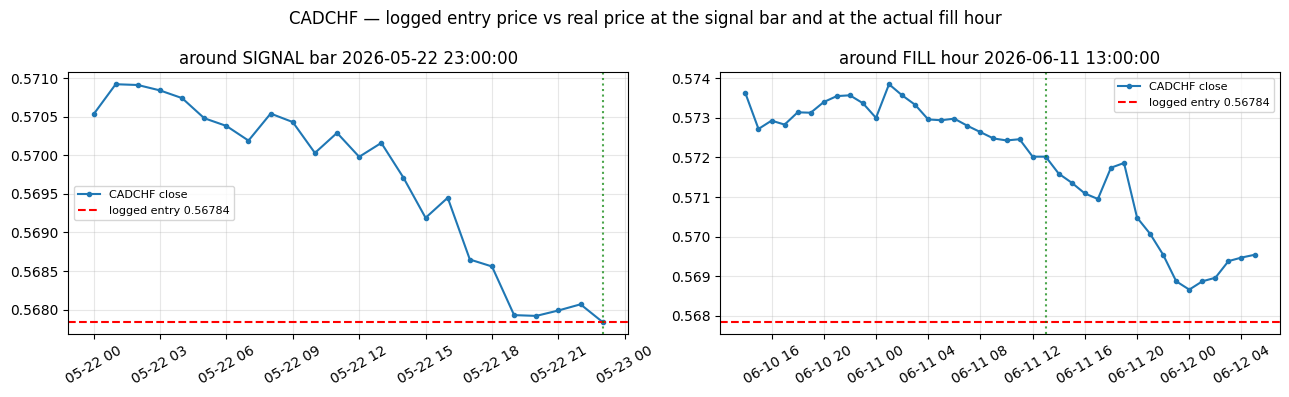

In [6]:
# --- visual: CADCHF, the signal_ts bar vs where the bot really was at fill time ---
sym = 'CADCHF'
entry = fills[(fills.symbol == sym) & (fills.kind == 'entry')].iloc[0]
sig_ts = pd.Timestamp(entry['signal_ts']).floor('h')
fill_hr = pd.Timestamp(entry['fill_ts']).floor('h')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, center, title in [(ax[0], sig_ts, f'around SIGNAL bar {sig_ts}'),
                          (ax[1], fill_hr, f'around FILL hour {fill_hr}')]:
    d = pull_h1(sym, center)
    a.plot(d.index, d['close'], '-o', ms=3, label=f'{sym} close')
    a.axhline(float(entry['intended_price']), color='r', ls='--', label=f"logged entry {entry['intended_price']:.5f}")
    a.axvline(center, color='g', ls=':', alpha=0.7)
    a.set_title(title); a.legend(fontsize=8); a.grid(alpha=0.3)
    a.tick_params(axis='x', rotation=30)
plt.suptitle('CADCHF — logged entry price vs real price at the signal bar and at the actual fill hour')
plt.tight_layout(); plt.show()

In [7]:
mt5.shutdown()
print('done — see the verdict table above.')

done — see the verdict table above.


## How to read the result

* `logged_in_bar_range = True` for an **entry** but its `signal_ts` is weeks before the `fill_ts`
  → the price is *technically real* but for the **wrong (stale) bar**. That is the bug.
* `logged_vs_real_pips` on **entries** being large (hundreds of pips) while **exits** ~0 confirms
  entries were booked on stale data and exits on live data, so the realised PnL is an artifact.

### Root cause
On the first cycle after `mt5.initialize()`, freshly `symbol_select`'d symbols return old cached
history; `DataFeed.pull` inner-joins all symbols and `dropna()` aligns to the **oldest latest-bar**,
dragging the whole panel back ~3 weeks. The bot opened every position at those stale prices.

### Fix (to apply in `statarb_live`)
1. **Staleness guard** in `orchestrator.run_cycle`: if `now - panel.last_ts > N` bars, skip the
   cycle (`cycle_skipped: stale data`) — never trade on a stale panel.
2. **Warm-up on connect**: after selecting symbols, re-fetch until the latest bar is current
   (or simply let the staleness guard skip the first cycle until MT5 has loaded fresh history).
3. **No-new-bar guard**: also fixes the weekend `equity.ts` duplicate-insert errors.